# Task 4 — DISARM Knowledge Graph Memory Layer (Cognee + OpenAI)

**Run cells strictly top to bottom. Do not skip any cell.**

### Full Pipeline:
1. Install & configure
2. Load FIMI dataset + parsed article texts
3. **Ingest DISARM technique definitions** (Dataset 1 — reference knowledge base)
4. **Ingest FIMI incidents gradually** (Dataset 2 — N train incidents)
5. **Evaluate on held-out test incidents** — compare retrieved vs ground-truth techniques
6. Gradual N experiment → find sweet spot
7. Save all results


## 1. Install

In [ ]:
!pip -q install "cognee>=1.0.1" pandas openpyxl matplotlib
print("Install done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.8/256.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.7/129.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 10.7 MB/s eta 0:00:00
   ━━

## 2. Set Environment Variables

> **Must run before `import cognee`** — cognee reads env vars at import time.

In [ ]:
import os
from google.colab import userdata

OPENAI_KEY = userdata.get("OPENAI_API_KEY")
assert OPENAI_KEY and OPENAI_KEY.startswith("sk-"), \
    "OPENAI_API_KEY secret missing — check Colab Secrets (key icon, left sidebar)"

os.environ["LLM_PROVIDER"]               = "openai"
os.environ["LLM_MODEL"]                  = "gpt-4o-mini"
os.environ["LLM_API_KEY"]                = OPENAI_KEY
os.environ["OPENAI_API_KEY"]             = OPENAI_KEY

os.environ["EMBEDDING_PROVIDER"]         = "openai"
os.environ["EMBEDDING_MODEL"]            = "text-embedding-3-small"
os.environ["EMBEDDING_API_KEY"]          = OPENAI_KEY
os.environ["EMBEDDING_DIMENSIONS"]       = "1536"

# Redirect DB to /content/ — prevents RAM crashes
os.environ["DATA_PATH"]                  = "/content/cognee_data"
os.environ["SYSTEM_ROOT_PATH"]           = "/content/cognee_system"

# v1.0.1 stability flags
os.environ["ENABLE_BACKEND_ACCESS_CONTROL"] = "false"
os.environ["CACHING"]                       = "false"
os.environ["COGNEE_CHUNKS_PER_BATCH"]       = "1"

print("Env vars set. Key prefix:", OPENAI_KEY[:8])

Env vars set. Key prefix: sk-proj-


## 3. Import Cognee + Force Config

In [ ]:
import cognee
from cognee import SearchType

cognee.config.set_llm_provider("openai")
cognee.config.set_llm_model("gpt-4o-mini")
cognee.config.set_llm_api_key(OPENAI_KEY)
cognee.config.set_embedding_provider("openai")
cognee.config.set_embedding_model("text-embedding-3-small")
cognee.config.set_embedding_api_key(OPENAI_KEY)
cognee.config.set_embedding_dimensions(1536)

print("Cognee configured.")


2026-04-22T20:35:21.357298 [info     ] Log file created at: /root/.cognee/logs/2026-04-22_20-35-20.log [cognee.shared.logging_utils] log_file=/root/.cognee/logs/2026-04-22_20-35-20.log

2026-04-22T20:35:21.359092 [warning  ] Cognee 1.0 changes: New API — remember/recall/forget/improve (V1 add/cognify/search still work). Session memory enabled by default (CACHING=false to disable). Multi-user access control on by default (ENABLE_BACKEND_ACCESS_CONTROL=false to disable). Agents (@cognee.agent) auto-verified on registration. See https://docs.cognee.ai/ [cognee.shared.logging_utils]

2026-04-22T20:35:21.360869 [info     ] Logging initialized            [cognee.shared.logging_utils] cognee_version=1.0.1 database_path=/usr/local/lib/python3.12/dist-packages/cognee/.cognee_system/databases os_info='Linux 6.6.113+ (#1 SMP Mon Feb  2 12:27:57 UTC 2026)' python_version=3.12.13 structlog_version=25.5.0

2026-04-22T20:35:21.362117 [info     ] Database storage: /usr/local/lib/python3.12/dist-packa

Cognee configured.


In [ ]:
import re
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

print("Imports OK.")


NumExpr defaulting to 2 threads.


Imports OK.


## 4. Mount Google Drive & Load Dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Adjust paths if needed ────────────────────────────────────────────────────
DRIVE_BASE          = "/content/drive/MyDrive/NLP"
DATA_PATH           = os.path.join(DRIVE_BASE, "data")
PARSED_MD_PATH      = os.path.join(DATA_PATH, "parsed_markdown")
DATASET_PATH        = "/content/fimi_dataset.csv"
DISARM_REPO_PATH    = "/content/DISARMframeworks"   # cloned in next section
DISARM_TECH_PATH    = os.path.join(DISARM_REPO_PATH, "generated_pages", "techniques")
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATASET_PATH, header=1)
first_col = df.columns[0]
df = df[df[first_col] != first_col].reset_index(drop=True)
df["incident_id"] = (df.index + 1).astype(str)

print("Shape:", df.shape)
print("incident_id sample:", df["incident_id"].head(5).tolist())
df.head(3)

Shape: (81, 155)
incident_id sample: ['1', '2', '3', '4', '5']


,Year,Target Country,Event,Region,Sub-region,Country of Origin,Threat Actor,Event description,T0002_Facilitate State Propaganda,T0072_Segment Audiences,...,Attribution Source: Researchers/Journalists,Source 1,Source 2,Source 3,Source 4,Source 5,Source 6,Source 7,Source 8,incident_id
0,2014,Scotland,Referendum,Europe,Western Europe,Russia*,IRA*,Referendum on the independence of Scotland,0,0,...,0,https://medium.com/dfrlab/electionwatch-scotti...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2014,Scotland,Referendum,Europe,Western Europe,Iran,IRIB,Referendum on the independence of Scotland,1,0,...,0,https://www.heraldscotland.com/news/16592877.f...,https://www.mandiant.com/resources/blog/suspec...,https://www.washingtonpost.com/news/democracy-...,Taking Down More Coordinated Inauthentic Behav...,https://public-assets.graphika.com/reports/gra...,NaN,NaN,NaN,2
2,2014,Ukraine,Presidential Election,Europe,Eastern Europe,Russia,GRU,Ukraine Presidential Election,1,0,...,1,https://www.washingtonpost.com/world/national-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


In [ ]:
SOURCE_COLS = [c for c in df.columns if str(c).startswith("Source")]

TECHNIQUE_COLS = [
    c for c in df.columns
    if re.match(r"^T\d{4}", str(c).strip())
]

print(f"Source columns   : {len(SOURCE_COLS)}")
print(f"Technique columns: {len(TECHNIQUE_COLS)}")
print("Sample:", TECHNIQUE_COLS[:5])

Source columns   : 8
Technique columns: 107
Sample: ['T0002_Facilitate State Propaganda', 'T0072_Segment Audiences', 'T0072.001_Geographic Segmentation', 'T0072.002_Demographic Segmentation', 'T0072.005_Political Segmentation']


## 5. Load Parsed Article Texts

In [ ]:
def read_text_file(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return f.read().strip()
    except Exception:
        return ""

def collect_article_texts(parsed_md_path):
    grouped = {}
    for path in glob.glob(os.path.join(parsed_md_path, "*.md")):
        fname = os.path.basename(path)
        m = re.match(r"^(.+?)_Source_\d+\.md$", fname, re.IGNORECASE)
        if not m:
            continue
        iid  = m.group(1).strip()
        text = read_text_file(path)
        if text:
            grouped.setdefault(iid, []).append(text)

    article_texts = {}
    for iid, texts in grouped.items():
        seen, unique = set(), []
        for t in texts:
            if t not in seen:
                seen.add(t)
                unique.append(t)
        article_texts[iid] = "\n\n--- ARTICLE SEPARATOR ---\n\n".join(unique)
    return article_texts

article_texts = collect_article_texts(PARSED_MD_PATH)
print(f"Loaded article texts for {len(article_texts)} incidents.")
matched = sum(1 for iid in df["incident_id"] if iid in article_texts)
print(f"Incidents with matching article text: {matched}/{len(df)}")

Loaded article texts for 71 incidents.
Incidents with matching article text: 70/81


## 6. Incident Chunk Builder

In [ ]:
def extract_active_techniques(row, technique_cols):
    return [
        col for col in technique_cols
        if pd.notna(row.get(col)) and
           str(row.get(col)).strip().lower() not in ("", "0", "false", "nan", "none")
    ]

def build_incident_chunk(row, article_texts, source_cols, technique_cols, max_article_chars=4000):
    iid        = str(row.get("incident_id", row.name))
    techniques = extract_active_techniques(row, technique_cols)

    meta_lines = [f"- incident_id: {iid}"]
    for field in ["Adversary", "Threat Actor", "Region", "Target Event", "Country", "Election Type"]:
        if field in row.index:
            v = row.get(field)
            if pd.notna(v) and str(v).strip():
                meta_lines.append(f"- {field}: {v}")

    source_lines = [
        f"- {col}: {row.get(col)}"
        for col in source_cols
        if pd.notna(row.get(col)) and str(row.get(col)).strip()
    ]

    article_text = article_texts.get(iid, "No article text available.")
    article_text = article_text[:max_article_chars]

    return f"""## FIELDS OF THE DATASET
{chr(10).join(meta_lines)}

## SOURCE URLS
{chr(10).join(source_lines) if source_lines else "- No sources listed"}

## ARTICLE TEXT
{article_text}

## ASSOCIATED TECHNIQUES
{chr(10).join(f"- {t}" for t in techniques) if techniques else "- None listed"}""".strip()

sample = build_incident_chunk(df.iloc[0], article_texts, SOURCE_COLS, TECHNIQUE_COLS)
print(f"Sample chunk: {len(sample)} chars (~{len(sample)//4} tokens)")
print(sample[:600])

Sample chunk: 4599 chars (~1149 tokens)
## FIELDS OF THE DATASET
- incident_id: 1
- Threat Actor: IRA*
- Region: Europe 

## SOURCE URLS
- Source 1: https://medium.com/dfrlab/electionwatch-scottish-vote-pro-kremlin-trolls-f3cca45045bb

## ARTICLE TEXT
Casey Michel is a reporter with ThinkProgress, covering money laundering and corruption. Four years ago, as Scotland moved toward its independence referendum, a Facebook page popped up aiming to push Edinburgh toward secession. “Free Scotland 2014” posted the kind of material that Facebook users know well, from links to strange “news” sites to memes mocking the rich and powerful.

All 


## 7. Clone DISARM Repo

This gives us the technique `.md` files — each contains the technique ID, name, description and examples.
These form **Dataset 1** (the reference knowledge base).

In [ ]:
import os

if not os.path.exists(DISARM_REPO_PATH):
    !git clone --depth=1 https://github.com/DISARMFoundation/DISARMframeworks.git {DISARM_REPO_PATH}
else:
    print("Repo already cloned.")

tech_files = glob.glob(os.path.join(DISARM_TECH_PATH, "*.md"))
print(f"Found {len(tech_files)} technique .md files.")
print("Sample:", [os.path.basename(f) for f in tech_files[:5]])

Cloning into '/content/DISARMframeworks'...
remote: Enumerating objects: 2808, done.
remote: Counting objects: 100% (2808/2808), done.
remote: Compressing objects: 100% (1305/1305), done.
remote: Total 2808 (delta 2072), reused 1636 (delta 1500), pack-reused 0 (from 0)
Receiving objects: 100% (2808/2808), 12.98 MiB | 17.92 MiB/s, done.
Resolving deltas: 100% (2072/2072), done.
Found 391 technique .md files.
Sample: ['T0097.100.md', 'T0044.md', 'T0152.010.md', 'T0084.001.md', 'T0016.md']


## 8. Ingest DISARM Technique Definitions (Dataset 1)

Each technique `.md` file is ingested as its own dataset: `technique_T0004`, `technique_T0022` etc.
This is the **reference knowledge base** — it tells cognee what each technique *means*.

> This only needs to run **once**. Do not prune between this and the incident ingestion.

In [13]:
# Get only the techniques that appear in your dataset
active_technique_ids = set()
for col in TECHNIQUE_COLS:
    # Extract just the ID part e.g. "T0004" from "T0004_Facilitate State Propaganda"
    match = re.match(r"^(T\d{4}(?:\.\d{3})?)", col)
    if match:
        active_technique_ids.add(match.group(1))

print(f"Unique techniques in dataset: {len(active_technique_ids)}")
print(sorted(active_technique_ids)[:10])

Unique techniques in dataset: 107
['T0002', 'T0003', 'T0004', 'T0007', 'T0013', 'T0016', 'T0018', 'T0022', 'T0022.001', 'T0023']


In [35]:
import shutil

DB_PATH = "/usr/local/lib/python3.12/dist-packages/cognee/.cognee_system"

SAVE_PATH = "/content/drive/MyDrive/NLP/cognee_backup"
os.makedirs(SAVE_PATH, exist_ok=True)

shutil.copytree(DB_PATH, f"{SAVE_PATH}/cognee_system", dirs_exist_ok=True)
print("Saved!")

Saved!


In [ ]:
#DB_PATH = "/usr/local/lib/python3.12/dist-packages/cognee/.cognee_system"
#SAVE_PATH = "/content/drive/MyDrive/NLP/cognee_backup"

#shutil.copytree(f"{SAVE_PATH}/cognee_system", ACTUAL_DB_PATH, dirs_exist_ok=True)
#print("Restored! Skip ingestion cells.")

In [14]:
async def ingest_disarm_techniques(techniques_path: str, filter_ids: set = None):
    await cognee.prune.prune_data()
    await cognee.prune.prune_system(metadata=True)

    files = sorted(glob.glob(os.path.join(techniques_path, "*.md")))

    # Filter to only techniques present in the dataset
    if filter_ids:
        files = [f for f in files if any(
            os.path.basename(f).replace(".md", "").startswith(tid)
            for tid in filter_ids
        )]

    print(f"Ingesting {len(files)} technique files (filtered from 392)...")

    for i, path in enumerate(files, 1):
        technique_id = os.path.basename(path).replace(".md", "")
        text = read_text_file(path)
        if not text:
            continue
        await cognee.add(text, dataset_name=f"technique_{technique_id.replace('.', '_')}")
        if i % 5 == 0 or i == len(files):
            print(f"  [{i}/{len(files)}] Added {technique_id}")

    print("\nRunning cognify...")
    await cognee.cognify()
    print("Done!")

await ingest_disarm_techniques(DISARM_TECH_PATH, filter_ids=active_technique_ids)


2026-04-22T20:57:01.069821 [info     ] Deleted Kuzu database files at /usr/local/lib/python3.12/dist-packages/cognee/.cognee_system/databases/cognee_graph_kuzu [cognee.shared.logging_utils]

2026-04-22T20:57:03.187152 [info     ] Database deleted successfully. [cognee.shared.logging_utils]

Deleting cache...             

✓ Cache deleted successfully! 


Ingesting 141 technique files (filtered from 392)...



User fac1e624-099f-4cc4-b981-50f2e7849d39 has registered.

2026-04-22T20:57:04.761327 [info     ] Pipeline run started: `57bc33f9-6acf-5502-8d2e-46af22126972` [run_tasks_with_telemetry()]

2026-04-22T20:57:04.763513 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T20:57:04.767025 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-04-22T20:57:04.872309 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-04-22T20:57:04.874350 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-04-22T20:57:04.877087 [info     ] Pipeline run completed: `57bc33f9-6acf-5502-8d2e-46af22126972` [run_tasks_with_telemetry()]

2026-04-22T20:57:05.187112 [info     ] Pipeline run started: `457c3d94-66f1-5e72-8b40-94534b239eb8` [run_tasks_with_telemetry()]

2026-04-22T20:57:05.190440 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T20:57:05.192037 [in

  [5/141] Added T0018



2026-04-22T20:57:07.156722 [info     ] Pipeline run started: `197c0f56-bcc3-513f-805c-497c0bb8ed42` [run_tasks_with_telemetry()]

2026-04-22T20:57:07.159124 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T20:57:07.161248 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-04-22T20:57:07.258347 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-04-22T20:57:07.260992 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-04-22T20:57:07.262734 [info     ] Pipeline run completed: `197c0f56-bcc3-513f-805c-497c0bb8ed42` [run_tasks_with_telemetry()]

2026-04-22T20:57:07.623984 [info     ] Pipeline run started: `fb02bd32-7c01-5123-9a67-0fef8ae1a18f` [run_tasks_with_telemetry()]

2026-04-22T20:57:07.625543 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T20:57:07.627247 [info     ] Coroutine task started: `ingest_data` [run_tasks_b

...

  [140/141] Added T0126.002



2026-04-22T20:58:10.968400 [info     ] Pipeline run started: `68be5ce2-e136-5fc2-b3db-4e34c663444e` [run_tasks_with_telemetry()]

2026-04-22T20:58:10.971102 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T20:58:10.972682 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-04-22T20:58:11.112445 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-04-22T20:58:11.114747 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-04-22T20:58:11.116670 [info     ] Pipeline run completed: `68be5ce2-e136-5fc2-b3db-4e34c663444e` [run_tasks_with_telemetry()]

2026-04-22T20:58:11.187651 [info     ] No ontology file provided. No owl ontology will be attached to the graph. [OntologyAdapter]

2026-04-22T20:58:11.319318 [info     ] Pipeline run started: `15e8623d-f530-5225-81da-e46ac9bb7ffd` [run_tasks_with_telemetry()]

2026-04-22T20:58:11.322477 [info     ] Coroutine task started: `c

  [141/141] Added T0126

Running cognify...


Streaming output truncated to the last 5000 lines.

2026-04-22T21:08:44.285677 [info     ] Coroutine task started: `extract_dlt_fk_edges` [run_tasks_base]

2026-04-22T21:08:44.287521 [info     ] Coroutine task completed: `extract_dlt_fk_edges` [run_tasks_base]

2026-04-22T21:08:44.291699 [info     ] Coroutine task completed: `add_data_points` [run_tasks_base]

2026-04-22T21:08:44.297426 [info     ] Coroutine task completed: `summarize_text` [run_tasks_base]

2026-04-22T21:08:44.298982 [info     ] Coroutine task completed: `extract_graph_from_data` [run_tasks_base]

2026-04-22T21:08:44.303127 [info     ] Async Generator task completed: `extract_chunks_from_documents` [run_tasks_base]

2026-04-22T21:08:44.305932 [info     ] Coroutine task completed: `classify_documents` [run_tasks_base]

2026-04-22T21:08:44.309539 [info     ] Pipeline run completed: `3bf48749-27d4-532b-b308-9a27d3bae7db` [run_tasks_with_telemetry()]

2026-04-22T21:08:44.452692 [info     ] Pipeline run started: `d508d8cd-

Done!


## 9. Train / Test Split

Split the FIMI dataset into:
- **Train**: incidents ingested into cognee (the memory layer sees these)
- **Test**: held-out incidents never ingested — used to evaluate retrieval

In [15]:
# ── Adjust these based on token budget ───────────────────────────────────────
N_TRAIN = 10   # incidents to ingest into cognee
N_TEST  = 5    # held-out incidents to evaluate on
# ─────────────────────────────────────────────────────────────────────────────

assert N_TRAIN + N_TEST <= len(df), "Not enough incidents in dataset"

train_df = df.iloc[:N_TRAIN].copy()
test_df  = df.iloc[N_TRAIN:N_TRAIN + N_TEST].copy()

print(f"Train incidents : {len(train_df)} (IDs: {train_df['incident_id'].tolist()})")
print(f"Test  incidents : {len(test_df)}  (IDs: {test_df['incident_id'].tolist()})")

Train incidents : 10 (IDs: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
Test  incidents : 5  (IDs: ['11', '12', '13', '14', '15'])


## 10. Ingest Train Incidents (Dataset 2)

Ingest N train incidents **without pruning** (techniques are already in the graph).
Each incident becomes its own dataset: `incident_1`, `incident_2` etc.

In [16]:
async def ingest_incidents(df_subset, article_texts, source_cols, technique_cols, prune_first=False):
    """
    Add FIMI incidents to the existing cognee graph.
    prune_first=False by default — do NOT wipe the technique definitions.
    """
    if prune_first:
        await cognee.prune.prune_data()
        await cognee.prune.prune_system(metadata=True)
        print("Pruned previous cognee state.")

    total = len(df_subset)
    for i, (idx, row) in enumerate(df_subset.iterrows(), 1):
        iid          = str(row.get("incident_id", idx))
        dataset_name = f"incident_{iid.replace('.', '_')}"
        chunk        = build_incident_chunk(row, article_texts, source_cols, technique_cols)
        await cognee.add(chunk, dataset_name=dataset_name)
        print(f"  [{i}/{total}] incident {iid} -> {dataset_name} ({len(chunk)} chars)")

    print("\nRunning cognify on incidents...")
    await cognee.cognify()
    print("Incident knowledge graph built successfully!")

# Ingest all train incidents (no prune — keep technique definitions)
await ingest_incidents(train_df, article_texts, SOURCE_COLS, TECHNIQUE_COLS, prune_first=False)


2026-04-22T21:41:11.874345 [info     ] Pipeline run started: `3de7ef59-7417-5b8d-bc98-3b10cb27a6df` [run_tasks_with_telemetry()]

2026-04-22T21:41:11.877617 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T21:41:11.882010 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-04-22T21:41:12.026719 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-04-22T21:41:12.031135 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-04-22T21:41:12.034658 [info     ] Pipeline run completed: `3de7ef59-7417-5b8d-bc98-3b10cb27a6df` [run_tasks_with_telemetry()]


  [1/10] incident 1 -> incident_1 (4599 chars)



2026-04-22T21:41:12.994177 [info     ] Pipeline run started: `ac843e21-c0f4-51e9-ac53-14cb7334cc93` [run_tasks_with_telemetry()]

2026-04-22T21:41:13.000520 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T21:41:13.006627 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-04-22T21:41:13.238944 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-04-22T21:41:13.242323 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-04-22T21:41:13.248255 [info     ] Pipeline run completed: `ac843e21-c0f4-51e9-ac53-14cb7334cc93` [run_tasks_with_telemetry()]


  [2/10] incident 2 -> incident_2 (5239 chars)



2026-04-22T21:41:13.866261 [info     ] Pipeline run started: `de76eb36-0319-5895-b5df-0601e37bed92` [run_tasks_with_telemetry()]

2026-04-22T21:41:13.872506 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T21:41:13.877898 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-04-22T21:41:14.054035 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-04-22T21:41:14.059269 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-04-22T21:41:14.061272 [info     ] Pipeline run completed: `de76eb36-0319-5895-b5df-0601e37bed92` [run_tasks_with_telemetry()]


...

  [9/10] incident 9 -> incident_9 (4567 chars)



2026-04-22T21:41:20.517829 [info     ] Pipeline run started: `1ec503d8-f53c-5a8f-88af-5169d5ce53a5` [run_tasks_with_telemetry()]

2026-04-22T21:41:20.521434 [info     ] Coroutine task started: `resolve_data_directories` [run_tasks_base]

2026-04-22T21:41:20.523203 [info     ] Coroutine task started: `ingest_data` [run_tasks_base]

2026-04-22T21:41:20.645238 [info     ] Coroutine task completed: `ingest_data` [run_tasks_base]

2026-04-22T21:41:20.647551 [info     ] Coroutine task completed: `resolve_data_directories` [run_tasks_base]

2026-04-22T21:41:20.650530 [info     ] Pipeline run completed: `1ec503d8-f53c-5a8f-88af-5169d5ce53a5` [run_tasks_with_telemetry()]

2026-04-22T21:41:20.716223 [info     ] No ontology file provided. No owl ontology will be attached to the graph. [OntologyAdapter]

2026-04-22T21:41:20.792428 [info     ] Dataset e561deee-a0b8-5b09-9ba8-209120f5ce08 is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:41:20.8

  [10/10] incident 10 -> incident_10 (5714 chars)

Running cognify on incidents...



2026-04-22T21:41:20.946964 [info     ] Dataset 26a6998b-4795-5396-bfb7-5fceac2cc8b2 is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:41:20.975803 [info     ] Dataset 17e715da-d676-5d91-a546-4822314eef76 is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:41:21.001109 [info     ] Dataset d9881bbc-e465-5604-8305-c89a733be252 is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:41:21.027884 [info     ] Dataset 6fa4d34a-75df-5d91-ad6a-eff40fec7bdf is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:41:21.052450 [info     ] Dataset 2b6ed232-5acd-548b-9120-275def5c2bf1 is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:41:21.078967 [info     ] Dataset ebe5eae7-23c5-581d-b338-64cc70fcd4cb is already processed. [cognee.modules.pipelin

Incident knowledge graph built successfully!


## 11. Query Helper

In [17]:
async def run_query(query: str, search_type=SearchType.GRAPH_COMPLETION, datasets=None):
    """
    Query the cognee knowledge graph.

    Args:
        query       : Natural language question.
        search_type : SearchType.GRAPH_COMPLETION  -- graph traversal + LLM (best)
                      SearchType.RAG_COMPLETION    -- classic vector similarity + LLM
        datasets    : list of dataset names to restrict scope.
                      None = search all datasets (techniques + incidents).
    Returns:
        List of result strings.
    """
    results = await cognee.search(
        query_text=query,
        query_type=search_type,
        datasets=datasets
    )
    return [str(r) for r in results]

## 12. Basic Queries on the Full Graph

In [18]:
q1 = await run_query("Summarize the foreign information operation in incident 1.")
q2 = await run_query("What DISARM techniques are associated with these incidents?")
q3 = await run_query("Which incidents involve election-related information operations?")

print("── Q1: Summary ──────────────────────────────────────────")
for r in q1: print(r)
print("\n── Q2: DISARM Techniques ────────────────────────────────")
for r in q2: print(r)
print("\n── Q3: Election Ops ─────────────────────────────────────")
for r in q3: print(r)


2026-04-22T21:43:36.549623 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.56s [cognee.shared.logging_utils]

2026-04-22T21:43:36.553636 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:43:36.733225 [info     ] ID-filtered retrieval: 1059 nodes and 1647 edges in 0.18s [cognee.shared.logging_utils]

2026-04-22T21:43:36.843617 [info     ] Graph projection completed: 1059 nodes, 1647 edges in 0.11s [CogneeGraph]

2026-04-22T21:43:36.885810 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 18, 'connection_count': 10}

2026-04-22T21:43:39.920687 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.89s [cognee.shared.logging_utils]

2026-04-22T21:43:39.923592 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x78960dce05c0

── Q1: Summary ──────────────────────────────────────────
In incident 1, the foreign information operation involved Russian and Iranian trolls manipulating Canadian politics during the 2015 election. Russian trolls supported conservative figures while criticizing Prime Minister Justin Trudeau, whereas Iranian trolls aligned with far-left perspectives. Both groups converged in their support for Bashar Assad in Syria and demonstrated animosity towards the Syrian White Helmets. They disseminated false narratives, attacked politicians, and utilized techniques such as creating inauthentic news articles and local personas to amplify their disinformation campaigns.

── Q2: DISARM Techniques ────────────────────────────────
The DISARM techniques associated with the incidents are:

1. **T0097.101: Local Persona** - Used to create the appearance of local support for narratives by impersonating or fabricating local individuals.
2. **T0143.002: Fabricated Persona** - Involves creating false identi

## 13. Search Type Comparison

In [19]:
EVAL_QUERY = "What DISARM techniques were used in foreign information operations targeting elections?"

search_type_results = {}
for stype in [SearchType.GRAPH_COMPLETION, SearchType.RAG_COMPLETION]:
    print(f"\n{'='*55}\nSearchType: {stype.name}\n{'='*55}")
    results = await run_query(EVAL_QUERY, search_type=stype)
    search_type_results[stype.name] = results
    for r in results: print(r) if results else print("No results.")


SearchType: GRAPH_COMPLETION



2026-04-22T21:44:04.979941 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.79s [cognee.shared.logging_utils]

2026-04-22T21:44:04.982835 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:44:05.087273 [info     ] ID-filtered retrieval: 1045 nodes and 1694 edges in 0.10s [cognee.shared.logging_utils]

2026-04-22T21:44:05.149025 [info     ] Graph projection completed: 1045 nodes, 1694 edges in 0.06s [CogneeGraph]

2026-04-22T21:44:05.172062 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 18, 'connection_count': 10}


The DISARM techniques used in foreign information operations targeting elections include:

1. **Facilitate State Propaganda**: Organizing citizens around pro-state messaging and coordinating groups to promote state propaganda.
2. **Control Information Environment through Offensive Cyberspace Operations**: Using cyber tools to prioritize operational messaging and block opposing viewpoints.
3. **Local Persona**: Presenting individuals as locals to amplify narratives and misrepresent local opinions, often involving fabricated locals.
4. **Government Official Persona**: Impersonating or leveraging actual government officials to lend credibility to disinformation narratives.
5. **Identify Target Audience Adversaries**: Creating or designating real or imagined adversaries to direct narratives against.
6. **Delete Opposing Content**: Removing content that conflicts with operational narratives to censor contradictory information.

SearchType: RAG_COMPLETION
DISARM techniques used in foreign in

## 14. Evaluate on Held-Out Test Incidents

For each test incident:
1. Query cognee with **only the article text** (no ground-truth techniques)
2. Parse retrieved techniques from the response
3. Compare against ground-truth technique labels from the dataset
4. Compute Precision, Recall, F1

In [27]:
def get_ground_truth_techniques(row, technique_cols):
    """Get the actual annotated techniques for an incident from the dataset."""
    return set(extract_active_techniques(row, technique_cols))


def compute_metrics(predicted: set, ground_truth: set) -> dict:
    if not ground_truth:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0,
                "predicted": len(predicted), "ground_truth": 0, "correct": 0}
    correct   = len(predicted & ground_truth)
    precision = correct / len(predicted) if predicted else 0.0
    recall    = correct / len(ground_truth)
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    return {
        "precision":    round(precision, 3),
        "recall":       round(recall, 3),
        "f1":           round(f1, 3),
        "predicted":    len(predicted),
        "ground_truth": len(ground_truth),
        "correct":      correct,
        "predicted_techniques":    list(predicted),
        "ground_truth_techniques": list(ground_truth),
    }

print("Evaluation functions defined.")

def parse_techniques_from_response(response_text: str, technique_cols: list) -> set:
    """
    Extract technique IDs from cognee response and match to dataset column names.
    Handles both exact matches and parent-technique matches.
    e.g. T0097.111 → matches T0097_Create Personas
    """
    found = set()
    matches = re.findall(r'T\d{4}(?:\.\d{3})?', response_text)

    for m in matches:
        parent_id = m.split(".")[0]  # e.g. T0097.111 → T0097
        for col in technique_cols:
            col_id = col.split("_")[0]  # e.g. T0097_Create Personas → T0097
            # Match if exact ID or parent ID matches
            if col_id == m or col_id == parent_id:
                found.add(col)

    return found

Evaluation functions defined.


In [26]:
async def evaluate_on_test_set(test_df, article_texts, technique_cols):
    eval_results = []

    for _, row in test_df.iterrows():
        iid          = str(row.get("incident_id", row.name))
        ground_truth = get_ground_truth_techniques(row, technique_cols)

        article_text = article_texts.get(iid, "")
        if not article_text:
            print(f"  Incident {iid}: no article text, skipping.")
            continue

        # More specific prompt — list all technique IDs explicitly
        technique_list = ", ".join([
            col.split("_")[0] for col in technique_cols
        ])

        query = f"""An article describes the following foreign information operation:

{article_text[:1500]}

From the DISARM framework, which of these specific techniques were used: {technique_list[:500]}?

List only the technique IDs that directly match actions described in the article above."""

        response = await run_query(query, SearchType.GRAPH_COMPLETION)
        response_text = " ".join(response)

        predicted = parse_techniques_from_response(response_text, technique_cols)
        metrics   = compute_metrics(predicted, ground_truth)
        metrics["incident_id"] = iid
        metrics["response"]    = response_text[:500]

        eval_results.append(metrics)
        print(f"  Incident {iid}: precision={metrics['precision']:.2f}  "
              f"recall={metrics['recall']:.2f}  f1={metrics['f1']:.2f}  "
              f"({metrics['correct']}/{metrics['ground_truth']} correct)")

    return eval_results

eval_results = await evaluate_on_test_set(test_df, article_texts, TECHNIQUE_COLS)

avg_precision = sum(r["precision"] for r in eval_results) / len(eval_results)
avg_recall    = sum(r["recall"]    for r in eval_results) / len(eval_results)
avg_f1        = sum(r["f1"]        for r in eval_results) / len(eval_results)
print(f"\nAvg Precision: {avg_precision:.3f}")
print(f"Avg Recall   : {avg_recall:.3f}")
print(f"Avg F1       : {avg_f1:.3f}")


2026-04-22T21:51:12.947219 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.57s [cognee.shared.logging_utils]

2026-04-22T21:51:12.950075 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:51:13.058512 [info     ] ID-filtered retrieval: 1052 nodes and 1794 edges in 0.11s [cognee.shared.logging_utils]

2026-04-22T21:51:13.121393 [info     ] Graph projection completed: 1052 nodes, 1794 edges in 0.06s [CogneeGraph]

2026-04-22T21:51:13.146873 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 14, 'connection_count': 10}


  Incident 11: precision=0.50  recall=0.17  f1=0.25  (2/12 correct)



2026-04-22T21:51:18.725332 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.04s [cognee.shared.logging_utils]

2026-04-22T21:51:18.728152 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:51:18.830375 [info     ] ID-filtered retrieval: 1063 nodes and 1763 edges in 0.10s [cognee.shared.logging_utils]

2026-04-22T21:51:18.891416 [info     ] Graph projection completed: 1063 nodes, 1763 edges in 0.06s [CogneeGraph]

2026-04-22T21:51:18.913213 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 15, 'connection_count': 10}


  Incident 12: precision=0.00  recall=0.00  f1=0.00  (0/17 correct)



2026-04-22T21:51:22.830791 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.86s [cognee.shared.logging_utils]

2026-04-22T21:51:22.835535 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:51:23.019642 [info     ] ID-filtered retrieval: 1062 nodes and 1786 edges in 0.18s [cognee.shared.logging_utils]

2026-04-22T21:51:23.115237 [info     ] Graph projection completed: 1062 nodes, 1786 edges in 0.09s [CogneeGraph]

2026-04-22T21:51:23.152082 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 14, 'connection_count': 10}


  Incident 13: precision=1.00  recall=0.04  f1=0.09  (2/44 correct)



2026-04-22T21:51:27.539300 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.92s [cognee.shared.logging_utils]

2026-04-22T21:51:27.542108 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:51:27.649860 [info     ] ID-filtered retrieval: 1061 nodes and 1799 edges in 0.11s [cognee.shared.logging_utils]

2026-04-22T21:51:28.238354 [info     ] Graph projection completed: 1061 nodes, 1799 edges in 0.59s [CogneeGraph]

2026-04-22T21:51:28.263149 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 16, 'connection_count': 10}


  Incident 14: precision=0.13  recall=0.58  f1=0.21  (7/12 correct)



2026-04-22T21:51:47.376360 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.01s [cognee.shared.logging_utils]

2026-04-22T21:51:47.379411 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:51:47.490228 [info     ] ID-filtered retrieval: 1064 nodes and 1786 edges in 0.11s [cognee.shared.logging_utils]

2026-04-22T21:51:47.556944 [info     ] Graph projection completed: 1064 nodes, 1786 edges in 0.07s [CogneeGraph]

2026-04-22T21:51:47.581245 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 14, 'connection_count': 10}


  Incident 15: precision=0.04  recall=0.33  f1=0.07  (2/6 correct)

Avg Precision: 0.334
Avg Recall   : 0.226
Avg F1       : 0.124


## 15. Gradual N-Incident Experiment

Key experiment: how does recall on test incidents change as we add more train incidents?
Finds the **sweet spot** — the N where performance stabilises.

In [28]:
async def gradual_evaluation_experiment(
    full_train_df, test_df, article_texts, technique_cols,
    max_n=None, step=1
):
    """
    For N = step, step*2, ..., max_n:
    1. Delete previous incident datasets (keep technique definitions)
    2. Ingest exactly first N train incidents fresh
    3. Evaluate on held-out test set
    4. Record precision, recall, F1
    """
    max_n = max_n or len(full_train_df)
    recall_by_n, precision_by_n, f1_by_n = {}, {}, {}

    for n in range(step, max_n + 1, step):
        print(f"\n── N={n} ────────────────────────────────────────────")

        # Delete previous incident datasets — keeps technique definitions intact
        incident_datasets = [
            f"incident_{str(row['incident_id']).replace('.', '_')}"
            for _, row in full_train_df.iterrows()
        ]
        for ds in incident_datasets:
            try:
                await cognee.delete(dataset_name=ds)
            except Exception:
                pass  # dataset may not exist yet on first iteration

        # Ingest exactly N incidents fresh
        subset = full_train_df.iloc[:n].copy()
        await ingest_incidents(subset, article_texts, SOURCE_COLS,
                               TECHNIQUE_COLS, prune_first=False)

        # Evaluate on held-out test set
        results = await evaluate_on_test_set(test_df, article_texts, technique_cols)
        if results:
            recall_by_n[n]    = round(sum(r["recall"]    for r in results) / len(results), 3)
            precision_by_n[n] = round(sum(r["precision"] for r in results) / len(results), 3)
            f1_by_n[n]        = round(sum(r["f1"]        for r in results) / len(results), 3)
            print(f"  N={n}: recall={recall_by_n[n]:.3f}  "
                  f"precision={precision_by_n[n]:.3f}  "
                  f"f1={f1_by_n[n]:.3f}")

    return recall_by_n, precision_by_n, f1_by_n


# ── Run ───────────────────────────────────────────────────────────────────────
recall_by_n, precision_by_n, f1_by_n = await gradual_evaluation_experiment(
    train_df, test_df, article_texts, TECHNIQUE_COLS,
    max_n=N_TRAIN, step=2   # step=2 saves time: runs N=2,4,6,8,10
)


── N=2 ────────────────────────────────────────────


/tmp/ipykernel_31210/157953356.py:25: DeprecationWarning: Call to deprecated function (or staticmethod) delete. (cognee.delete is deprecated. Use `datasets.delete_data` instead.) -- Deprecated since version 0.3.9.
  await cognee.delete(dataset_name=ds)


  [1/2] incident 1 -> incident_1 (4599 chars)



2026-04-22T21:57:08.014185 [info     ] No ontology file provided. No owl ontology will be attached to the graph. [OntologyAdapter]

2026-04-22T21:57:08.083482 [info     ] Dataset e561deee-a0b8-5b09-9ba8-209120f5ce08 is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:57:08.109598 [info     ] Dataset 6bfbbb06-fd5a-587a-a16f-f86d0416babd is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:57:08.136969 [info     ] Dataset 799ff4ad-9e89-551a-a333-8ebfcaae83a3 is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:57:08.162503 [info     ] Dataset cddac5b7-8599-5e2c-9ace-0cac362f5424 is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification]

2026-04-22T21:57:08.189803 [info     ] Dataset 3f2f84ee-c221-5b0b-a45d-ff543a64c1ff is already processed. [cognee.modules.pipelines.layers.check_pipeline_run_qualification

  [2/2] incident 2 -> incident_2 (5239 chars)

Running cognify on incidents...


...

  Incident 13: precision=0.67  recall=0.14  f1=0.23  (6/44 correct)



2026-04-22T21:59:08.200319 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.89s [cognee.shared.logging_utils]

2026-04-22T21:59:08.203273 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:59:08.332384 [info     ] ID-filtered retrieval: 1061 nodes and 1799 edges in 0.13s [cognee.shared.logging_utils]

2026-04-22T21:59:08.398645 [info     ] Graph projection completed: 1061 nodes, 1799 edges in 0.06s [CogneeGraph]

2026-04-22T21:59:08.424221 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 16, 'connection_count': 10}


  Incident 14: precision=0.00  recall=0.00  f1=0.00  (0/12 correct)



2026-04-22T21:59:11.619214 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.42s [cognee.shared.logging_utils]

2026-04-22T21:59:11.623991 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T21:59:11.749704 [info     ] ID-filtered retrieval: 1064 nodes and 1786 edges in 0.12s [cognee.shared.logging_utils]

2026-04-22T21:59:11.807992 [info     ] Graph projection completed: 1064 nodes, 1786 edges in 0.06s [CogneeGraph]

2026-04-22T21:59:11.833873 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 14, 'connection_count': 10}


  Incident 15: precision=0.04  recall=0.33  f1=0.07  (2/6 correct)
  N=10: recall=0.210  precision=0.167  f1=0.102


## 16. Plot: Performance vs Number of Incidents

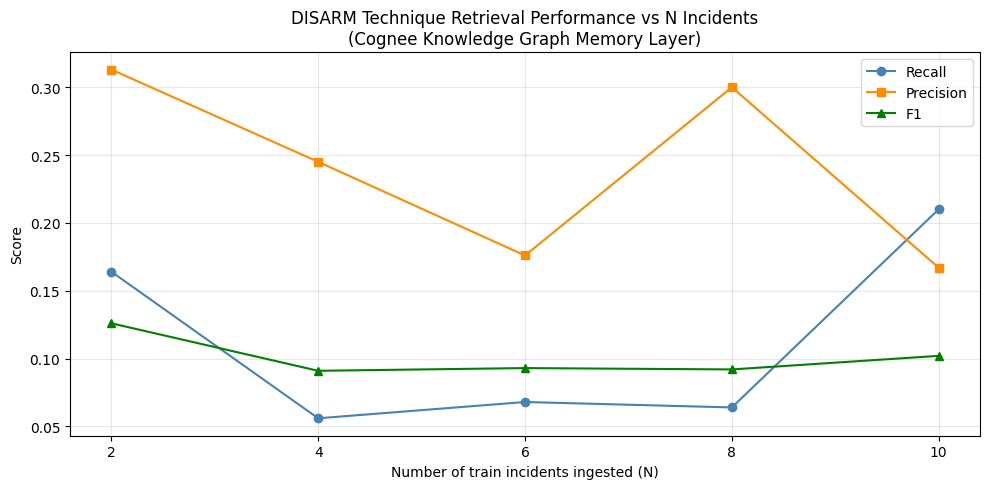

Plot saved to /content/gradual_experiment_plot.png

Sweet spot: N=10 incidents (recall=0.210)


In [29]:
ns         = sorted(recall_by_n.keys())
recalls    = [recall_by_n[n]    for n in ns]
precisions = [precision_by_n[n] for n in ns]
f1s        = [f1_by_n[n]        for n in ns]

plt.figure(figsize=(10, 5))
plt.plot(ns, recalls,    marker="o", label="Recall",    color="steelblue")
plt.plot(ns, precisions, marker="s", label="Precision", color="darkorange")
plt.plot(ns, f1s,        marker="^", label="F1",        color="green")

plt.xlabel("Number of train incidents ingested (N)")
plt.ylabel("Score")
plt.title("DISARM Technique Retrieval Performance vs N Incidents\n(Cognee Knowledge Graph Memory Layer)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(ns)
plt.tight_layout()
plt.savefig("/content/gradual_experiment_plot.png", dpi=150)
plt.show()
print("Plot saved to /content/gradual_experiment_plot.png")

# Find sweet spot
if recalls:
    sweet_spot = max(recall_by_n, key=recall_by_n.get)
    print(f"\nSweet spot: N={sweet_spot} incidents (recall={recall_by_n[sweet_spot]:.3f})")

## 17. Gradual Search-Scope Experiment

Original experiment: restrict *search scope* to first N datasets and count returned techniques.

In [30]:
async def gradual_scope_experiment(df, query, search_type=SearchType.GRAPH_COMPLETION, max_n=None):
    all_datasets = [
        f"incident_{str(row['incident_id']).replace('.', '_')}"
        for _, row in df.iterrows()
    ]
    max_n = max_n or len(all_datasets)
    results_by_n = {}

    for n in range(1, max_n + 1):
        subset  = all_datasets[:n]
        results = await cognee.search(
            query_text=query,
            query_type=search_type,
            datasets=subset
        )
        results_by_n[n] = [str(r) for r in results]
        print(f"N={n:3d} -> {len(results):3d} results")

    return results_by_n

gradual_scope = await gradual_scope_experiment(
    train_df,
    query="What DISARM techniques were used?",
    max_n=N_TRAIN
)


2026-04-22T22:00:11.180249 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 0.97s [cognee.shared.logging_utils]

2026-04-22T22:00:11.183560 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T22:00:11.290350 [info     ] ID-filtered retrieval: 1045 nodes and 1689 edges in 0.10s [cognee.shared.logging_utils]

2026-04-22T22:00:11.880393 [info     ] Graph projection completed: 1045 nodes, 1689 edges in 0.59s [CogneeGraph]

2026-04-22T22:00:11.900639 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 19, 'connection_count': 10}


N=  1 ->   1 results



2026-04-22T22:00:17.796664 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.00s [cognee.shared.logging_utils]

2026-04-22T22:00:17.799315 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T22:00:17.902306 [info     ] ID-filtered retrieval: 1045 nodes and 1689 edges in 0.10s [cognee.shared.logging_utils]

2026-04-22T22:00:17.963095 [info     ] Graph projection completed: 1045 nodes, 1689 edges in 0.06s [CogneeGraph]

2026-04-22T22:00:17.984852 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 19, 'connection_count': 10}


N=  2 ->   1 results



2026-04-22T22:00:22.644673 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.22s [cognee.shared.logging_utils]

2026-04-22T22:00:22.647227 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T22:00:22.765066 [info     ] ID-filtered retrieval: 1045 nodes and 1689 edges in 0.12s [cognee.shared.logging_utils]

2026-04-22T22:00:22.823566 [info     ] Graph projection completed: 1045 nodes, 1689 edges in 0.06s [CogneeGraph]

2026-04-22T22:00:22.843815 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 19, 'connection_count': 10}


...

N=  8 ->   1 results



2026-04-22T22:00:54.586823 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.09s [cognee.shared.logging_utils]

2026-04-22T22:00:54.588933 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T22:00:54.697212 [info     ] ID-filtered retrieval: 1045 nodes and 1689 edges in 0.11s [cognee.shared.logging_utils]

2026-04-22T22:00:54.765069 [info     ] Graph projection completed: 1045 nodes, 1689 edges in 0.07s [CogneeGraph]

2026-04-22T22:00:54.792120 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 19, 'connection_count': 10}


N=  9 ->   1 results



2026-04-22T22:01:01.034625 [info     ] Vector collection retrieval completed: Retrieved distances from 6 collections in 1.57s [cognee.shared.logging_utils]

2026-04-22T22:01:01.038806 [info     ] Retrieving ID-filtered graph from database. [CogneeGraph]

2026-04-22T22:01:01.206235 [info     ] ID-filtered retrieval: 1045 nodes and 1689 edges in 0.17s [cognee.shared.logging_utils]

2026-04-22T22:01:01.302956 [info     ] Graph projection completed: 1045 nodes, 1689 edges in 0.10s [CogneeGraph]

2026-04-22T22:01:01.336978 [info     ] Completed resolving edges to text [cognee.shared.logging_utils] extra={'node_count': 19, 'connection_count': 10}


N= 10 ->   1 results


## 18. Save All Results

In [31]:
output = {
    "q1_summary":             q1,
    "q2_disarm_techniques":   q2,
    "q3_election_ops":        q3,
    "search_type_comparison": search_type_results,
    "evaluation_per_incident": eval_results,
    "aggregate_metrics": {
        "avg_precision": round(avg_precision, 3),
        "avg_recall":    round(avg_recall, 3),
        "avg_f1":        round(avg_f1, 3),
        "n_test":        len(eval_results),
        "n_train":       N_TRAIN,
    },
    "gradual_evaluation": {
        "recall_by_n":    {str(k): v for k, v in recall_by_n.items()},
        "precision_by_n": {str(k): v for k, v in precision_by_n.items()},
        "f1_by_n":        {str(k): v for k, v in f1_by_n.items()},
    },
    "gradual_scope": {str(k): v for k, v in gradual_scope.items()},
}

with open("/content/cognee_results.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print("All results saved to /content/cognee_results.json")
print("Keys:", list(output.keys()))

All results saved to /content/cognee_results.json
Keys: ['q1_summary', 'q2_disarm_techniques', 'q3_election_ops', 'search_type_comparison', 'evaluation_per_incident', 'aggregate_metrics', 'gradual_evaluation', 'gradual_scope']


## 19. Print Saved Results

In [32]:
with open("/content/cognee_results.json", "r") as f:
    saved = json.load(f)

for key, value in saved.items():
    print(f"\n{'='*60}\n  {key}\n{'='*60}")
    if isinstance(value, list):
        for r in value: print(r)
    elif isinstance(value, dict):
        for k, v in value.items():
            print(f"\n  -- {k} --")
            if isinstance(v, list):
                for r in v: print(r)
            elif isinstance(v, dict):
                for kk, vv in v.items(): print(f"    {kk}: {vv}")
            else:
                print(v)


  q1_summary
In incident 1, the foreign information operation involved Russian and Iranian trolls manipulating Canadian politics during the 2015 election. Russian trolls supported conservative figures while criticizing Prime Minister Justin Trudeau, whereas Iranian trolls aligned with far-left perspectives. Both groups converged in their support for Bashar Assad in Syria and demonstrated animosity towards the Syrian White Helmets. They disseminated false narratives, attacked politicians, and utilized techniques such as creating inauthentic news articles and local personas to amplify their disinformation campaigns.

  q2_disarm_techniques
The DISARM techniques associated with the incidents are:

1. **T0097.101: Local Persona** - Used to create the appearance of local support for narratives by impersonating or fabricating local individuals.
2. **T0143.002: Fabricated Persona** - Involves creating false identities to lend credibility to narratives.
3. **T0143.003: Impersonated Persona** 